# Figure 5- Viol Stim Interactions


In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from violmulti.data.dataset_loader import DatasetLoader
from violmulti.experiments.experiment import load_experiment
from violmulti.utils.violation_iti import *
from violmulti.visualizations.model_visualizer import *
from violmulti.models.linear_regression import *
import config as c
from violmulti.data import ANIMAL_IDS
from violmulti.features.exp_filter import ExpFilter
from violmulti.features.design_matrix_generator_PWM import *

sns.set_context("talk")

%load_ext autoreload
%autoreload 2

DATA_PATH = "/Users/jessbreda/Desktop/github/violations-multinomial/data"

prev_viol_binary_itrx_exp = save_name = "2025_04_14_fig4_fit_binary_prev_viol_stim_intrx_n_rs47.pkl"

compare_exp = "2025_04_16_fig4_compare_intrxs_rs47.pkl"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
tdf = DatasetLoader().load_data()

DataLoader: Loading data for animal ids:  ['W051', 'W060', 'W065', 'W066', 'W068', 'W072', 'W073', 'W074', 'W075', 'W078', 'W080', 'W081', 'W083', 'W088', 'W089', 'W094']


# A post violation hit rate


In [99]:
# add prev violation to tdf
tdf["prev_violation"] = prev_violation(tdf)
# compute hit rates by violation history
hit_rates_by_viol_hist = tdf.groupby(["animal_id", "session", "prev_violation"])["hit"].mean().reset_index().groupby(["animal_id", "prev_violation"]).hit.mean().reset_index()

# pivot hit rates by violation history
wide_hit_rates = hit_rates_by_viol_hist.pivot(
    index="animal_id", columns="prev_violation", values="hit"
)
wide_hit_rates.columns = ["hit_rate_wo_prev_viol", "hit_rate_w_prev_viol"]

# multiply by 100
wide_hit_rates = wide_hit_rates * 100
wide_hit_rates.reset_index(inplace=True)

# save hit rates by violation history
wide_hit_rates.to_csv(
    "data/hit_rates_by_viol_hist.csv", index=False
)

wide_hit_rates.head()


,animal_id,hit_rate_wo_prev_viol,hit_rate_w_prev_viol
0,W051,80.348978,76.405413
1,W060,83.063119,78.309221
2,W065,77.697107,76.737056
3,W066,78.790194,79.291998
4,W068,77.936953,77.160832


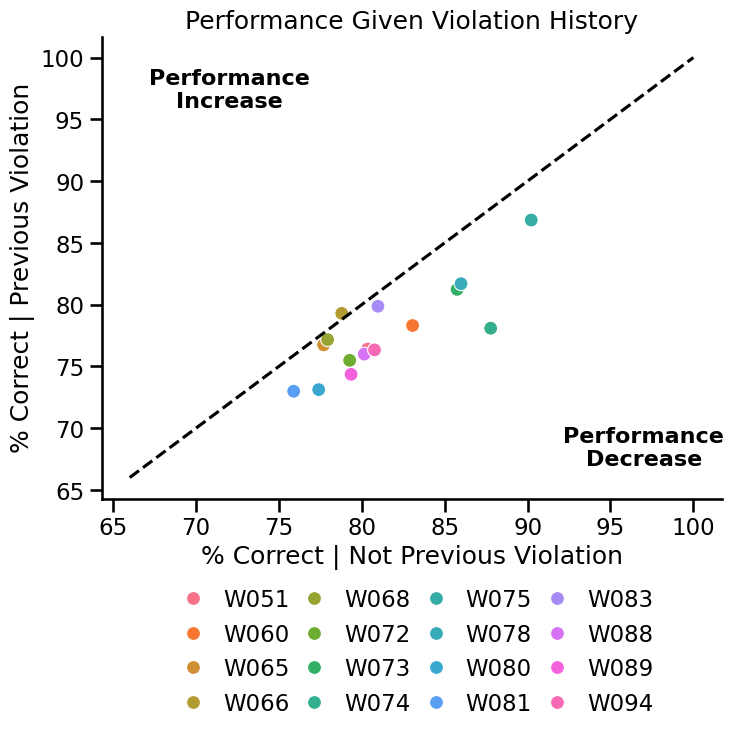

In [251]:
limits = (66, 100)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=wide_hit_rates, x="hit_rate_wo_prev_viol", y="hit_rate_w_prev_viol", s=100, hue="animal_id", ax=ax)

ax.plot(limits, limits, "k--")

ax.set_xlabel("% Correct | Not Previous Violation")
ax.set_ylabel("% Correct | Previous Violation")
ax.set_title("Performance Given Violation History")

ax.text(97, 67, "Performance\nDecrease", fontsize=16, fontweight="bold", ha="center")
ax.text(72, 96, "Performance\nIncrease", fontsize=16, fontweight="bold", ha="center")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    frameon=False,
    handletextpad=0.3,   # smaller = closer label to marker
    columnspacing=0.1    # smaller = less space between items
)

sns.despine()

plt.savefig("figures/fig4_hit_rates_by_viol_hist.png", dpi=300, bbox_inches="tight")

# B weights


In [130]:
ddf = pd.DataFrame()

ddf["trial"] = np.arange(1,11)
ddf["violation"] = [0,1,0,0,0,1,0,0,0,0]
ddf["prev_violation"] = [0,0,1,0,0,0,1,0,0,0]

filter = ExpFilter(tau=5)
filter.apply_filter_to_session("prev_violation", ddf)
max_val = ddf["prev_violation_exp"].max()
ddf["prev_violation_exp_norm"] = ddf["prev_violation_exp"] / (max_val + 0.12)

ex_data = tdf.query("animal_id == 'W072'").copy()
ddf["s_a"] = standardize(ex_data.s_a).values[:len(ddf)]
ddf["s_b"] = standardize(ex_data.s_b).values[:len(ddf)]
ddf["s_a_x_prev_violation"] = ddf["s_a"] * ddf["prev_violation"]

ddf.head()

ddf.to_csv("data/demo_intuition_data.csv", index=False)

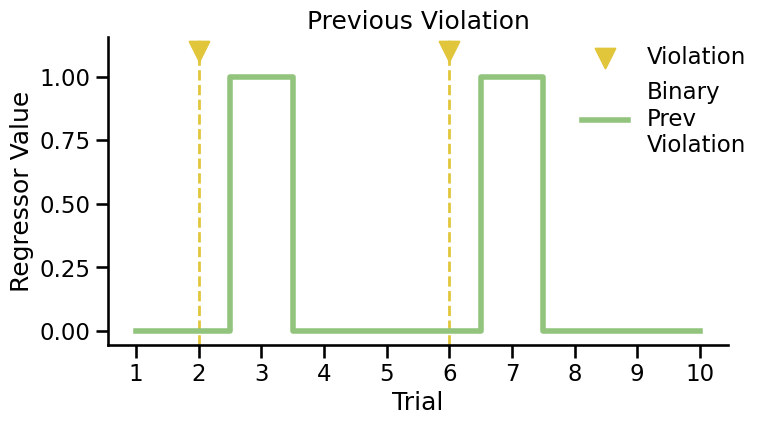

In [167]:
fig, ax = plt.subplots(figsize=(8, 4)) 

vddf = ddf.query("violation == 1")

ax.scatter(vddf["trial"], (vddf["violation"] + 0.1), color=c.VIOLATION_COLOR, marker="v", label="Violation", s=200)
for trial in vddf["trial"]:
    ax.axvline(x=trial, ymax=1.0, color=c.VIOLATION_COLOR, linestyle='--', linewidth=2)

sns.lineplot(x=ddf["trial"], y=ddf["prev_violation"], drawstyle='steps-mid', label="Binary\nPrev\nViolation", ax=ax, color=c.PREV_VIOLATION_COLOR, linewidth=4)

ax.legend(bbox_to_anchor=(.75, 1), loc='upper left', borderaxespad=0., frameon=False)

ax.set(
    ylabel="Regressor Value",
    xlabel="Trial",
    title="Previous Violation",
)

ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()

plt.savefig("figures/fig4b_prev_viol_weights_intuition.png", dpi=300, bbox_inches="tight")

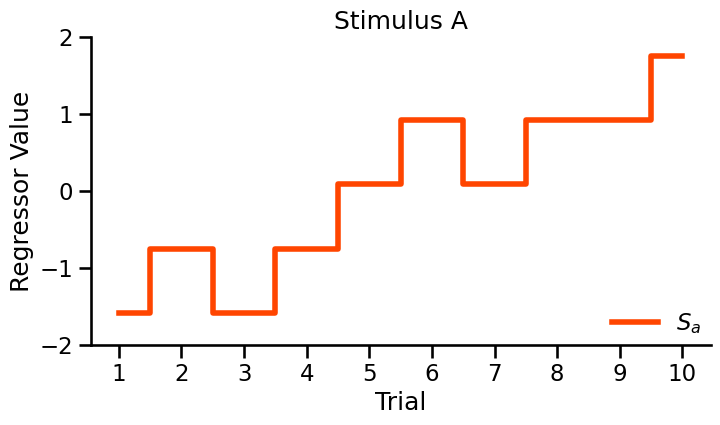

In [71]:
fig, ax = plt.subplots(figsize=(8, 4)) 


sns.lineplot(x=ddf["trial"], y=ddf["s_a"], drawstyle='steps-mid', label="$S_a$", ax=ax, color="orangered", linewidth=4)

ax.legend(loc="lower right", borderaxespad=0., frameon=False)

ax.set(
    ylabel="Regressor Value",
    xlabel="Trial",
    title="Stimulus A",
    ylim=(-2,2)
)

ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()

plt.savefig("figures/fig4b_Stimulus_A_weights_intuition.png", dpi=300, bbox_inches="tight")

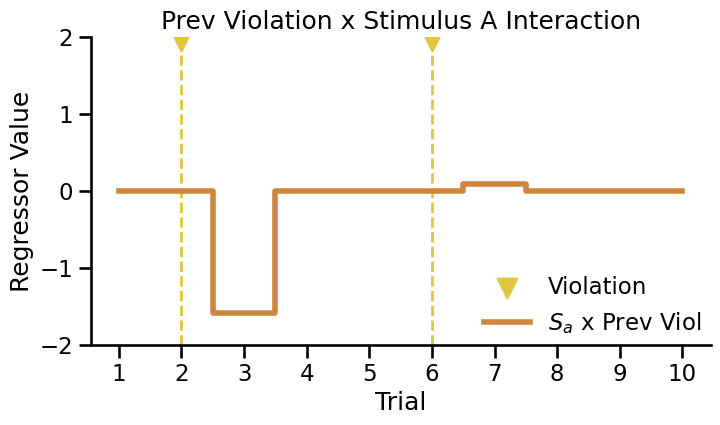

In [165]:
fig, ax = plt.subplots(figsize=(8, 4)) 


vddf = ddf.query("violation == 1")

ax.scatter(vddf["trial"], (vddf["violation"] + 0.95), color=c.VIOLATION_COLOR, marker="v", label="Violation", s=200)
for trial in vddf["trial"]:
    ax.axvline(x=trial, ymax=1.0, color=c.VIOLATION_COLOR, linestyle='--', linewidth=2)

sns.lineplot(x=ddf["trial"], y=ddf["s_a_x_prev_violation"], drawstyle='steps-mid', label="$S_a$ x Prev Viol", ax=ax, color="peru", linewidth=4)

ax.legend(loc="lower right", borderaxespad=0., frameon=False)

ax.set(
    ylabel="Regressor Value",
    xlabel="Trial",
    title="Prev Violation x Stimulus A Interaction",
    ylim=(-2,2)
)

ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()

plt.savefig("figures/fig4b_interaction_intuition.png", dpi=300, bbox_inches="tight")

## ii


In [50]:
mvpv = ModelVisualizer(load_experiment(prev_viol_binary_itrx_exp))
XMIN=-2.1
XMAX=2.1

In [289]:
ORDER = [
    "s_a", 
    "sa_x_prev_viol", 
    "s_b", 
    "sb_x_prev_viol",
    "prev_violation",
]
# Get the DataFrame
df = mvpv.unpack_features_and_weights().query("feature in @ORDER")

# If you want to reorder the features according to ORDER
df['feature'] = pd.Categorical(df['feature'], categories=ORDER, ordered=True)


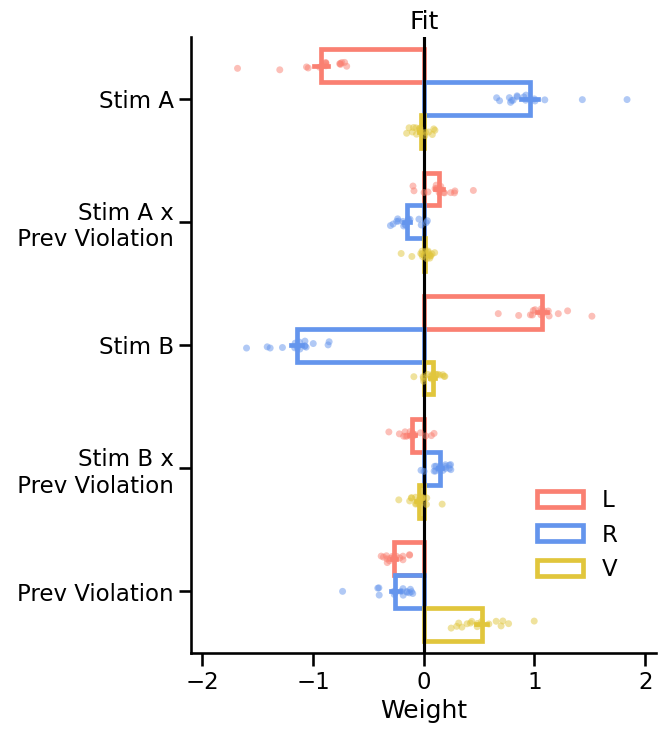

In [291]:
fig, ax = plt.subplots(figsize=(6, 8)) 

mvpv.plot_weights_summary(ax=ax,orientation="h", plot_bias = False, title="Fit", plot_individuals=True, seed=19, palette=c.MULTI_CHOICE_PAL, df=df)

ax.legend(bbox_to_anchor=(0.7, 0.3), frameon=False)

LABELS = [
    "Stim A", 
    "Stim A x\n Prev Violation",
    "Stim B", 
    "Stim B x\n Prev Violation",
    "Prev Violation", 
    # "Prev Stim Avg", 
    # "Prev Correct", 
    # "Prev Choice",
]

# set y labels
ax.set_yticks(range(len(LABELS)))
ax.set_yticklabels(LABELS)

# set x label
ax.set_xlabel("Weight")
ax.set_xlim(XMIN, XMAX)

plt.savefig("figures/fig4b_prev_viol_intrx_weights.png", dpi=300, bbox_inches="tight")

# C psychometric


In [168]:
from violmulti.utils.simulate_prev_viol_pyschometrics import SimulatePrevViolPyschometric


In [169]:
experiment = load_experiment(save_name)  
model_name = "prev_viol_binary_itrx"

In [172]:
sim_psych = SimulatePrevViolPyschometric(experiment, model_name)
PAL = ["gray", c.VIOLATION_COLOR]
STYLE_ORDER = [1, 0]


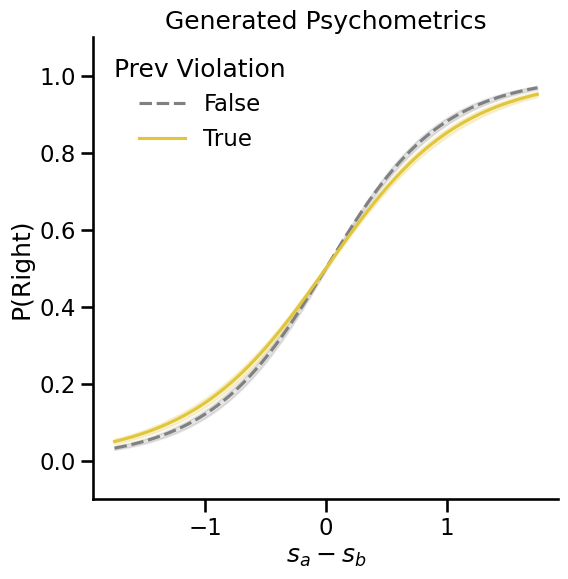

In [176]:
fig, ax = sim_psych.plot_summary(delta_range=(-1.75,1.75), title="Generated Psychometrics", palette=PAL, style_order=STYLE_ORDER)

fig.savefig("figures/fig4_psych_simulation.png", bbox_inches="tight", dpi=300)



In [177]:
results = sim_psych.extract_slope_and_lapse()

In [218]:
results["combined_lapse"] = results["upper_lapse"] + results["lower_lapse"]

In [219]:
results_melted =pd.melt(results, id_vars=["v_x"], value_vars=["slope", "combined_lapse", "upper_lapse", "lower_lapse"], value_name="value", var_name="metric").rename(columns={"v_x": "prev_violation"})


/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_9399/3143177735.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=plot_df, x="prev_violation", y="value", hue="prev_violation", palette=PAL, ax=ax, join=False, errorbar="se")


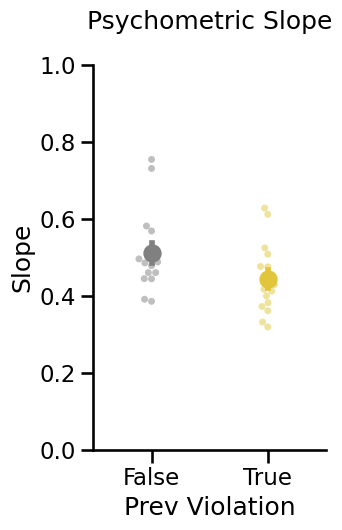

In [300]:
fig, ax = plt.subplots(figsize=(3, 5))
plot_df = results_melted.query("metric == 'slope'").copy()
plot_df["prev_violation"] = plot_df["prev_violation"].map({0: "False", 1: "True"})

sns.despine()
ax.set_title("Psychometric Slope\n")
_ =ax.set(ylabel="Slope", xlabel="Prev Violation")
ax.set_ylim(0, 1)

sns.pointplot(data=plot_df, x="prev_violation", y="value", hue="prev_violation", palette=PAL, ax=ax, join=False, errorbar="se")
sns.swarmplot(data=plot_df, x="prev_violation", y="value", hue="prev_violation", palette=PAL, ax=ax, alpha=0.5)

plt.savefig("figures/fig4_psych_slope.png", dpi=300, bbox_inches="tight")

/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_9399/3140874055.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=plot_df, x="prev_violation", y="value", hue="prev_violation", palette=PAL, ax=ax, join=False, errorbar="se")


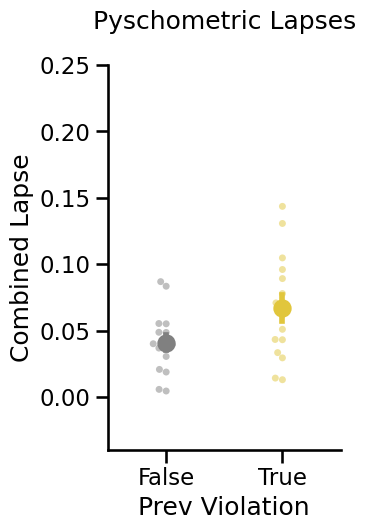

In [299]:
fig, ax = plt.subplots(figsize=(3, 5))
plot_df = results_melted.query("metric == 'combined_lapse'").copy()
plot_df["prev_violation"] = plot_df["prev_violation"].map({0: "False", 1: "True"})

sns.despine()
ax.set_title("Pyschometric Lapses\n")
_ =ax.set(ylabel="Combined Lapse", xlabel="Prev Violation")
ax.set_ylim(-.04, 0.25)

sns.pointplot(data=plot_df, x="prev_violation", y="value", hue="prev_violation", palette=PAL, ax=ax, join=False, errorbar="se")
sns.swarmplot(data=plot_df, x="prev_violation", y="value", hue="prev_violation", palette=PAL, ax=ax, alpha=0.5)

plt.savefig("figures/fig4_psych_lapses.png", dpi=300, bbox_inches="tight")

# D Compare


In [293]:
mvc = ModelVisualizerCompare(load_experiment(compare_exp))

ORDER = [
    "base",
    "prev_viol_binary",
    "prev_viol_binary_itrx",
    "prev_viol_filtered",
    "prev_viol_filtered_itrx",
]
LABELS = [
    "Base\nMulti-class",
    "+ Binary \nPrev Viol",
    "+ Binary \nPrev Viol\nw/ Intrxs",
    "+ Filtered \nPrev Viol",
    "+ Filtered \nPrev Viol\nw/ Intrxs",
]

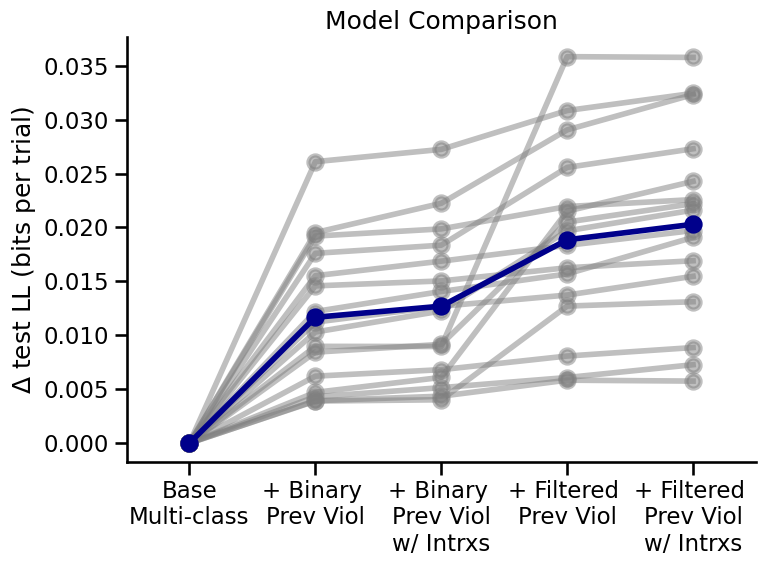

In [298]:
fig, ax = plt.subplots(figsize=(8,6
                                ))
sns.despine()
mvc.plot_model_comparison(
    hue="animal_id",
    ax=ax,
    order=ORDER,
    palette=["gray"] * 16,
    alpha = 0.5,
    y="bits_per_trial_relative_to_base"
)
mvc.plot_model_comparison(
    ax=ax,
    order=ORDER,
    color=c.MODEL_COMPARE_COLOR,
    errorbar=None,
    y="bits_per_trial_relative_to_base",
    ylabel="$\Delta$ test LL (bits per trial)",
)
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=0)
ax.legend().remove()
ax.set(xlabel="", title="Model Comparison")

# save fig
plt.tight_layout()
plt.savefig("figures/fig4_compare_prev_viol_and_intrxs.png", dpi=300, bbox_inches="tight")

In [270]:
bpt = mvc.compute_bits_per_trial_df()

bpt.groupby("model_name").bits_per_trial_relative_to_base.agg(["mean", "std"])


,mean,std
model_name,,
base,0.000000,0.000000
null,-1.775654,0.071471
prev_viol_binary,0.011669,0.006623
prev_viol_binary_itrx,0.012697,0.006916
prev_viol_filtered,0.018852,0.008682
prev_viol_filtered_itrx,0.020290,0.008969


In [272]:
ORDER[1:3]

['prev_viol_binary', 'prev_viol_binary_itrx']

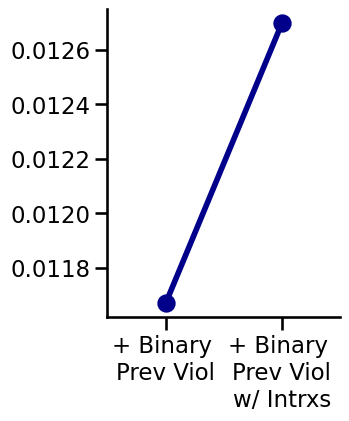

In [295]:
fig, ax = plt.subplots(figsize=(3,4))


models = ORDER[1:3]

sns.despine()


sns.pointplot(
    data=bpt.query("model_name in @models"),
    x="model_name",
    y="bits_per_trial_relative_to_base",
    ax=ax,
    order= models,
    color=c.MODEL_COMPARE_COLOR,
    errorbar=None,
)


ax.set_xticks(range(len(LABELS[1:3])))
ax.set_xticklabels(LABELS[1:3], rotation=0)

ax.set(xlabel="", title="", ylabel="")

# save fig
plt.savefig("figures/fig4_compare_prev_viol_and_intrxs_binary_hist_zoom.png", dpi=300, bbox_inches="tight")

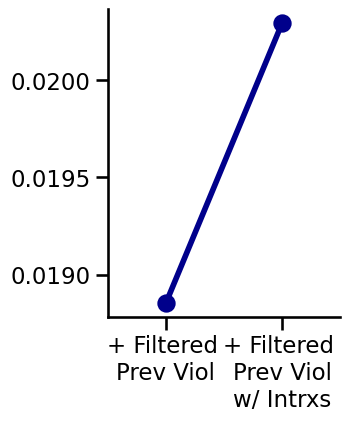

In [296]:
fig, ax = plt.subplots(figsize=(3,4))


models = ORDER[3:]

sns.despine()



sns.pointplot(
    data=bpt.query("model_name in @models"),
    x="model_name",
    y="bits_per_trial_relative_to_base",
    ax=ax,
    order= models,
    color=c.MODEL_COMPARE_COLOR,
    errorbar=None,
)


ax.set_xticks(range(len(LABELS[3:])))
ax.set_xticklabels(LABELS[3:], rotation=0)

ax.set(xlabel="", title="", ylabel="")


# save fig
plt.savefig("figures/fig4_compare_prev_viol_and_intrxs_filtered_hist_zoom.png", dpi=300, bbox_inches="tight")

## Base vs Intrx Filtered


In [261]:

mvc.compute_overall_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered_itrx")


/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:989: RuntimeWarning: overflow encountered in scalar power
  overall_ratio = 2 ** overall_diff_bits
/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:993: RuntimeWarning: overflow encountered in scalar power
  if np.isinf(2 ** overall_diff_bits):


{'overall_ratio': inf, 'log10_overall_ratio': 2488.0641759895393}

In [158]:

mvc.compute_geometric_mean_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered_itrx")


{'geometric_mean_ratio': 3.191618687982257e+155,
 'log10_geometric_mean_ratio': 155.5040109993462}

> On average, each animal's test data is $3.19 x 10^{155}$ or $10^{155}$ times more likely under the previous violation filtered model


## Filtered vs Intrx Filtered


In [262]:

mvc.compute_overall_ll_ratio(base_model_name="prev_viol_filtered", new_model_name="prev_viol_filtered_itrx")


{'overall_ratio': 2.768265790233539e+176,
 'log10_overall_ratio': 176.4422077858173}

In [263]:

mvc.compute_geometric_mean_ll_ratio(base_model_name="prev_viol_filtered", new_model_name="prev_viol_filtered_itrx")


{'geometric_mean_ratio': 106570741274.93971,
 'log10_geometric_mean_ratio': 11.027637986613579}

> On average, each animal's test data is $1.06 x 10^{11}$ or $10^{11}$ times more likely under the previous violation filtered model
